# [Global Temporal Split] ID-Only NCF Baseline

**Model:** Neural Collaborative Filtering (NCF) - ID embeddings only  
**Purpose:** Pure collaborative filtering baseline. No side features — only `user_id` and `book_id` embeddings.  
Establishes the performance floor that all feature-enhanced models must beat.

**Input files:** `App2_train.pkl`, `App2_val_ws.pkl`, `App2_test_ws.pkl`  

**Columns used:** `user_id`, `book_id`, `event_time` only.  
All other feature columns in the pkl files are ignored by this model.

**Evaluation (Val and Test Sets):** Validation and test ranking are conducted on fixed sampled lists of 5000 users stored in global_temporal_val_eval_sample_users.csv and global_temporal_test_eval_sample_5k_users.csv. These users are extracted from the warm-start subsets App2_val_ws.pkl and App2_test_ws.pkl, where cold-start users and items have already been removed so that every evaluated user and book is present in the training vocabulary.

## Caveat

The global temporal NCF results should not be interpreted as directly comparable to those of the within-user NCF model, because the two approaches differed not only in data splitting and validation design, but also in evaluation coverage.

This global temporal NCF was introduced to test a more leakage-conscious and evaluation-consistent setup. In this design, all interactions were ordered by timestamp at the dataset level and split into training, validation, and test sets based on global time, so that training data always preceded validation and test data chronologically. Cold-start users and items were then removed from validation and test, meaning that evaluation was conducted in a warm-start setting only. Validation and test were both performed using the same sampled ranking formulation, where each held-out positive interaction was ranked against 99 sampled negative items on a fixed sample of 5,000 users. This was intended to better align model selection with the final evaluation task.

By contrast, the within-user NCF split interactions by position within each user’s history, but its validation procedure was based on pointwise classification-style metrics rather than the same ranking task used at test time, due to computational constraints. This produced unusually inflated validation results, including near-perfect values, that were not directly comparable to the final test ranking metrics. In addition, the within-user setup did not benefit from the same warm-start filtering of cold-start users and items, making its evaluation setting less directly aligned with that of the global temporal model.

Therefore, differences in HR@10, MRR@10, and nDCG@10 between the two NCF variants may reflect not only model behavior, but also differences in split logic, validation protocol, and evaluation difficulty. The global temporal NCF should thus be interpreted as an alternative setup designed to reduce temporal leakage and better align validation with testing, rather than as a strict head-to-head benchmark against the within-user NCF.

# Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR  = '/content/drive/My Drive/BT4222Project/'

SEED = 4222
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = 10

print(f"Device : {DEVICE}")
print(f"K      : {K}")

Mounted at /content/drive
Device : cuda
K      : 10


# Load Splits

We load the global temporal train, validation, and test interaction files. The validation and test files are the **warm-start** subsets, meaning cold-start users and items have already been removed before this notebook.

For each split:
- `user_id` and `book_id` are cast to string
- `event_time` is parsed as datetime
- rows missing any core field (`user_id`, `book_id`, or `event_time`) are dropped
- rows are sorted by `user_id` and `event_time`



In [ ]:
train_df = pd.read_pickle(DATA_DIR + "App2_train.pkl")
val_df   = pd.read_pickle(DATA_DIR + "App2_val_ws.pkl")
test_df  = pd.read_pickle(DATA_DIR + "App2_test_ws.pkl")

for x in [train_df, val_df, test_df]:
    x["user_id"] = x["user_id"].astype(str)
    x["book_id"] = x["book_id"].astype(str)
    x["event_time"] = pd.to_datetime(x["event_time"], errors="coerce")
    x.dropna(subset=["user_id", "book_id", "event_time"], inplace=True)
    x.sort_values(["user_id", "event_time"], inplace=True)
    x.reset_index(drop=True, inplace=True)

# Keep only what ID-only NCF needs
COLS = ["user_id", "book_id", "event_time"]
train_df = train_df[COLS].copy()
val_df   = val_df[COLS].copy()
test_df  = test_df[COLS].copy()

print(f"Train : {len(train_df):,} rows  |  {train_df['user_id'].nunique():,} users | {train_df['book_id'].nunique():,} items")
print(f"Val   : {len(val_df):,} rows  |  {val_df['user_id'].nunique():,} users | {val_df['book_id'].nunique():,} items")
print(f"Test  : {len(test_df):,} rows  |  {test_df['user_id'].nunique():,} users | {test_df['book_id'].nunique():,} items")

Train : 7,454,809 rows  |  410,740 users | 114,452 items
Val   : 612,745 rows  |  85,098 users | 63,212 items
Test  : 259,317 rows  |  50,011 users | 45,529 items


In [ ]:
train_users = set(train_df["user_id"].unique())
train_items = set(train_df["book_id"].unique())

assert set(val_df["user_id"].unique()).issubset(train_users)
assert set(test_df["user_id"].unique()).issubset(train_users)
assert set(val_df["book_id"].unique()).issubset(train_items)
assert set(test_df["book_id"].unique()).issubset(train_items)

print("Warm-start checks passed.")

Warm-start checks passed.


# Label Encoding


*  Fit encoders on the training set only




In [ ]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

user_enc.fit(train_df["user_id"])
item_enc.fit(train_df["book_id"])

num_users = len(user_enc.classes_)
num_items = len(item_enc.classes_)

# Train-set density
N_train = len(train_df)
density_train = N_train / (num_users * num_items)

print(f"Train users (U)       : {num_users:,}")
print(f"Train items (I)       : {num_items:,}")
print(f"Train interactions    : {N_train:,}")
print(f"Train density         : {density_train * 100:.6f}%")

# Overall split sizes for reference
N_all = len(train_df) + len(val_df) + len(test_df)
print(f"Total rows (all splits): {N_all:,}")

def encode_df(df, user_enc, item_enc):
    user_mask = df["user_id"].isin(user_enc.classes_)
    item_mask = df["book_id"].isin(item_enc.classes_)

    d = df.loc[user_mask & item_mask].copy()
    d["user_idx"] = user_enc.transform(d["user_id"])
    d["item_idx"] = item_enc.transform(d["book_id"])
    return d

train_enc = encode_df(train_df, user_enc, item_enc)
val_enc   = encode_df(val_df, user_enc, item_enc)
test_enc  = encode_df(test_df, user_enc, item_enc)

print(f"\nEncoded train : {len(train_enc):,} rows")
print(f"Encoded val   : {len(val_enc):,} rows")
print(f"Encoded test  : {len(test_enc):,} rows")

print("\nRows dropped during encoding:")
print(f"Val dropped   : {len(val_df) - len(val_enc):,}")
print(f"Test dropped  : {len(test_df) - len(test_enc):,}")

assert len(train_enc) == len(train_df), "Train should not lose rows during encoding"
assert len(val_enc) == len(val_df), "Some val rows were unexpectedly dropped during encoding"
assert len(test_enc) == len(test_df), "Some test rows were unexpectedly dropped during encoding"

print("\nEncoding coverage checks passed.")

Train users (U)       : 410,740
Train items (I)       : 114,452
Train interactions    : 7,454,809
Train density         : 0.015858%
Total rows (all splits): 8,326,871

Encoded train : 7,454,809 rows
Encoded val   : 612,745 rows
Encoded test  : 259,317 rows

Rows dropped during encoding:
Val dropped   : 0
Test dropped  : 0

Encoding coverage checks passed.


## Negative Sampling (Top-1000 Popular Books)

*   All train interactions are implicit positives (label=1).  
*   For each user, negative samples (label = 0) are drawn from the top-1000 most interacted books in the training set, excluding books the user has already seen in the training set.

**Why top-1000 only:**  
Sampling from all 116k books for every user would be computationally expensive. Restricting negatives to popular books creates harder negatives: books the user was more likely to have encountered but did not interact with in training. This provides a stronger learning signal than sampling random obscure books.

**1:1 positive:negative ratio:**

For each user, the code samples up to one negative per positive training interaction, subject to how many unseen books remain in the top-1000 candidate pool.


In [ ]:
from time import perf_counter
from tqdm.auto import tqdm

start_t = perf_counter()

# Pre-compute top-1000 most popular books from TRAIN ONLY

top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)
print(f"Top-1000 pool size: {len(top_1000_books)}")

# Keep only books that exist in the train-fitted item encoder
top_1000_books = [b for b in top_1000_books if b in set(item_enc.classes_)]
top_1000_idx = item_enc.transform(top_1000_books)

# User history from TRAIN ONLY

user_train_history_idx = (
    train_enc.groupby("user_id")["item_idx"]
    .apply(set)
    .to_dict()
)

# Build training positives
pos = train_enc[["user_idx", "item_idx"]].copy()
pos["label"] = 1

# Pre-compute maps/arrays used in the negative sampling loop
user_pos_counts = train_enc.groupby("user_id", sort=False).size()
user_to_idx = (
    train_enc.drop_duplicates("user_id")
    .set_index("user_id")["user_idx"]
    .to_dict()
)

rng = np.random.default_rng(SEED)
neg_user_chunks = []
neg_item_chunks = []

for user_id, n_pos in tqdm(
    user_pos_counts.items(),
    total=len(user_pos_counts),
    desc="Negative sampling",
    unit="user"
):
    seen_idx = user_train_history_idx.get(user_id, set())

    if seen_idx:
        pool_idx = top_1000_idx[~np.isin(top_1000_idx, list(seen_idx))]
    else:
        pool_idx = top_1000_idx

    n_neg = min(int(n_pos), int(pool_idx.size))
    if n_neg == 0:
        continue

    sampled_idx = rng.choice(pool_idx, size=n_neg, replace=False)
    neg_user_chunks.append(np.full(n_neg, user_to_idx[user_id], dtype=np.int32))
    neg_item_chunks.append(sampled_idx.astype(np.int32))

if neg_user_chunks:
    neg = pd.DataFrame({
        "user_idx": np.concatenate(neg_user_chunks),
        "item_idx": np.concatenate(neg_item_chunks),
        "label": np.zeros(sum(len(x) for x in neg_user_chunks), dtype=np.int8),
    })
else:
    neg = pd.DataFrame(columns=["user_idx", "item_idx", "label"])

train_with_neg = (
    pd.concat([pos, neg], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Train positives          : {len(pos):,}")
print(f"Train negatives          : {len(neg):,}")
print(f"Train rows (with negs)   : {len(train_with_neg):,}")
print("\nLabel counts:")
print(train_with_neg["label"].value_counts())
print(f"\nNegative sampling time: {perf_counter() - start_t:.1f}s")

Top-1000 pool size: 1000


Negative sampling:   0%|          | 0/410740 [00:00<?, ?user/s]

Train positives          : 7,454,809
Train negatives          : 7,104,278
Train rows (with negs)   : 14,559,087

Label counts:
label
1    7454809
0    7104278
Name: count, dtype: int64

Negative sampling time: 22.2s


# Dataset and Data Loader



* After applying a **global temporal split** to the interactions data. The model is trained on `App2_train.pkl`, while validation and test use the warm-start subsets (`App2_val_ws.pkl`, `App2_test_ws.pkl`) so that all evaluated users and items are already present in the training vocabulary (no-cold start users or items).




In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class GoodreadsDataset(Dataset):
    def __init__(self, df):
        self.users  = torch.tensor(df["user_idx"].values, dtype=torch.long)
        self.items  = torch.tensor(df["item_idx"].values, dtype=torch.long)
        self.labels = torch.tensor(df["label"].values,    dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

train_loader = DataLoader(
    GoodreadsDataset(train_with_neg),
    batch_size=512,
    shuffle=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val positives : {len(val_enc):,} rows")
print(f"Test positives: {len(test_enc):,} rows")

Train batches : 28436
Val positives : 612,745 rows
Test positives: 259,317 rows


# ID-Only NCF Model

Only `user_embedding` and `book_embedding` — no side features.

Architecture:
- User embedding (32-dim) + Book embedding (32-dim) → concat (64-dim)
- MLP: 64 → 256 → ReLU → 64 → BatchNorm → ReLU → Dropout(0.5) → 1

In [ ]:
class NCFModel(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)
        return self.mlp(x).squeeze(1)

model = NCFModel(num_users, num_items, embedding_dim=32).to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

NCFModel(
  (user_embedding): Embedding(410740, 32)
  (item_embedding): Embedding(114452, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 16,839,425


# Evaluation Metrics

HitRate@K, MAP@K, nDCG@K







In [ ]:
def metrics_from_positive_rank(rank, k):
    hr = 1.0 if rank <= k else 0.0
    mrr = 1.0 / rank if rank <= k else 0.0
    ndcg = 1.0 / np.log2(rank + 1) if rank <= k else 0.0
    return hr, mrr, ndcg

print("Metric functions ready.")

Metric functions ready.


# Ranking Evaluation Setup



* Create a candidate pool of the top 1000 most popular books from the training set only (no cold-start items)

* Verifies that evaluation users (in validation and test sets) are also present in the training set (no cold-start users)

* This ensures that ranking evaluation is performed only on users and books the model can represent





In [ ]:
import random

# Train-only user history
user_train_seen = train_df.groupby("user_id")["book_id"].apply(set).to_dict()

# True positive items per user
val_true_items_per_user = val_df.groupby("user_id")["book_id"].apply(list).to_dict()
test_true_items_per_user = test_df.groupby("user_id")["book_id"].apply(list).to_dict()

# Lookup dicts
item_to_idx = {item: idx for idx, item in enumerate(item_enc.classes_)}
user_to_idx = {u: idx for idx, u in enumerate(user_enc.classes_)}

# Top-1000 popular books from train only
top_1000_books = (
    train_df.groupby("book_id").size()
    .sort_values(ascending=False)
    .head(1000)
    .index.tolist()
)

# Keep only books in encoder vocab
top_1000_books = [b for b in top_1000_books if b in item_to_idx]

# Validation users
val_eval_users = []
for uid, books in val_true_items_per_user.items():
    if uid not in user_to_idx:
        continue
    valid_books = [b for b in books if b in item_to_idx]
    if valid_books:
        val_eval_users.append((uid, valid_books))

# Test users
test_eval_users = []
for uid, books in test_true_items_per_user.items():
    if uid not in user_to_idx:
        continue
    valid_books = [b for b in books if b in item_to_idx]
    if valid_books:
        test_eval_users.append((uid, valid_books))

print(f"Val users for ranking eval : {len(val_eval_users):,}")
print(f"Test users for ranking eval: {len(test_eval_users):,}")
print(f"Top-1000 candidate pool    : {len(top_1000_books):,}")

Val users for ranking eval : 85,098
Test users for ranking eval: 50,011
Top-1000 candidate pool    : 1,000


# Ranking Evaluation Function

In [ ]:
from tqdm.auto import tqdm
import torch
import numpy as np
import random

def evaluate_ranking_sampled_fast(
    model,
    eval_users,
    user_train_seen,
    item_to_idx,
    user_to_idx,
    candidate_book_ids,
    device,
    k,
    n_neg,
    seed=4222,
):
    rng = random.Random(seed)
    model.eval()

    hr_list = []
    mrr_list = []
    ndcg_list = []

    with torch.no_grad():
        for uid, true_books in tqdm(eval_users, desc="Ranking eval", leave=False):
            if uid not in user_to_idx:
                continue

            uidx = user_to_idx[uid]

            target_book = true_books[0]
            if target_book not in item_to_idx:
                continue

            seen = user_train_seen.get(uid, set()) | set(true_books)
            neg_pool = [b for b in candidate_book_ids if b not in seen]

            if len(neg_pool) == 0:
                continue

            sampled_negs = rng.sample(neg_pool, min(n_neg, len(neg_pool)))
            candidates = [target_book] + sampled_negs
            candidate_idx = np.array([item_to_idx[b] for b in candidates], dtype=np.int64)

            u_t = torch.tensor([uidx] * len(candidate_idx), dtype=torch.long, device=device)
            i_t = torch.tensor(candidate_idx, dtype=torch.long, device=device)

            scores = torch.sigmoid(model(u_t, i_t)).cpu().numpy()

            target_score = scores[0]
            rank = 1 + np.sum(scores[1:] > target_score)

            hr, mrr, ndcg = metrics_from_positive_rank(rank, k)
            hr_list.append(hr)
            mrr_list.append(mrr)
            ndcg_list.append(ndcg)

    n_users = len(hr_list)
    if n_users == 0:
        return {
            "n_users": 0,
            f"HR@{k}": 0.0,
            f"MRR@{k}": 0.0,
            f"nDCG@{k}": 0.0,
        }

    return {
        "n_users": n_users,
        f"HR@{k}": float(np.mean(hr_list)),
        f"MRR@{k}": float(np.mean(mrr_list)),
        f"nDCG@{k}": float(np.mean(ndcg_list)),
    }

# Creating Sample of 5000 users from warm-start subsets App2_val_ws.pkl and App2_test_ws.pkl (don't rerun)

In [ ]:
MAX_VAL_EVAL_USERS = 5000
MAX_TEST_EVAL_USERS = 5000

random.seed(SEED)

if len(val_eval_users) > MAX_VAL_EVAL_USERS:
    val_eval_users_sampled = random.sample(val_eval_users, MAX_VAL_EVAL_USERS)
else:
    val_eval_users_sampled = val_eval_users

if len(test_eval_users) > MAX_TEST_EVAL_USERS:
    test_eval_users_sampled = random.sample(test_eval_users, MAX_TEST_EVAL_USERS)
else:
    test_eval_users_sampled = test_eval_users

print(f"Val users total    : {len(val_eval_users):,}")
print(f"Val users sampled  : {len(val_eval_users_sampled):,}")
print(f"Test users total   : {len(test_eval_users):,}")
print(f"Test users sampled : {len(test_eval_users_sampled):,}")

# Save sampled user IDs for reuse
val_sample_user_ids = [uid for uid, _ in val_eval_users_sampled]
test_sample_user_ids = [uid for uid, _ in test_eval_users_sampled]

pd.DataFrame({"user_id": val_sample_user_ids}).to_csv(
    DATA_DIR + "global_temporal_val_eval_sample_users.csv",
    index=False
)

pd.DataFrame({"user_id": test_sample_user_ids}).to_csv(
    DATA_DIR + "global_temporal_test_eval_sample_5k_users.csv",
    index=False
)

print("\nSaved sampled user lists:")
print(DATA_DIR + "global_temporal_val_eval_sample_users.csv")
print(DATA_DIR + "global_temporal_test_eval_sample_5k_users.csv")

Val users total    : 85,098
Val users sampled  : 5,000
Test users total   : 50,011
Test users sampled : 5,000

Saved sampled user lists:
/content/drive/My Drive/BT4222Project/global_temporal_val_eval_sample_users.csv
/content/drive/My Drive/BT4222Project/global_temporal_test_eval_sample_5k_users.csv


Load Samples

In [ ]:
val_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_val_eval_sample_users.csv"
).iloc[:, 0].astype(str).tolist()

test_sample_user_ids = pd.read_csv(
    DATA_DIR + "global_temporal_test_eval_sample_5k_users.csv"
).iloc[:, 0].astype(str).tolist()

print(f"Loaded {len(val_sample_user_ids):,} val sampled users")
print(f"Loaded {len(test_sample_user_ids):,} test sampled users")

val_sample_user_id_set = set(val_sample_user_ids)
test_sample_user_id_set = set(test_sample_user_ids)

val_eval_users_sampled = [
    (uid, books) for uid, books in val_eval_users
    if uid in val_sample_user_id_set
]

test_eval_users_sampled = [
    (uid, books) for uid, books in test_eval_users
    if uid in test_sample_user_id_set
]

print(f"Val users total    : {len(val_eval_users):,}")
print(f"Val users sampled  : {len(val_eval_users_sampled):,}")
print(f"Test users total   : {len(test_eval_users):,}")
print(f"Test users sampled : {len(test_eval_users_sampled):,}")

Loaded 5,000 val sampled users
Loaded 5,000 test sampled users
Val users total    : 85,098
Val users sampled  : 5,000
Test users total   : 50,011
Test users sampled : 5,000


## Training — BCEWithLogitsLoss

The model is trained on the sampled implicit-feedback dataset using **BCEWithLogitsLoss** and the **Adam** optimiser. At each epoch, training loss is computed over mini-batches of positive and negative user–item pairs.

Model selection is based on **ranking validation**, not training loss alone. After each epoch, the model is evaluated on the sampled validation users using **HR@10**, **MRR@10**, and **nDCG@10**, and the checkpoint with the best **validation nDCG@10** is saved. **Early stopping** with patience of 5 epochs is applied to prevent overtraining.

During validation, each user is ranked against **99 sampled negative books**. This is used for two reasons:
- it keeps validation computationally feasible, since ranking evaluation is performed after every epoch
- it still aligns validation with the final recommendation task, because the model is selected using **top-K ranking metrics** rather than pointwise classification accuracy alone

Training loss and validation ranking metrics are plotted across epochs to monitor both optimisation and recommendation quality.

Epoch progress:   0%|          | 0/10 [00:00<?, ?epoch/s]

Train E01:   0%|          | 0/28436 [00:00<?, ?batch/s]

Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 01/10  Train Loss: 0.3914  Train Acc: 0.8231  Val HR@10: 0.7990  Val MRR@10: 0.6755  Val nDCG@10: 0.7051  Val Users: 5,000
  Saved best model locally (global_temporal_best_ncf_idonly.pt) (val nDCG@10: 0.7051)


Train E02:   0%|          | 0/28436 [00:00<?, ?batch/s]

...

Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 08/10  Train Loss: 0.2731  Train Acc: 0.8809  Val HR@10: 0.8028  Val MRR@10: 0.6654  Val nDCG@10: 0.6980  Val Users: 5,000
  No improvement. Patience: 4/5


Train E09:   0%|          | 0/28436 [00:00<?, ?batch/s]

Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 09/10  Train Loss: 0.2661  Train Acc: 0.8843  Val HR@10: 0.8008  Val MRR@10: 0.6621  Val nDCG@10: 0.6950  Val Users: 5,000
  No improvement. Patience: 5/5

Early stopping at epoch 9.

Best model also saved to Drive: /content/drive/My Drive/BT4222Project/global_temporal_best_ncf_idonly.pt


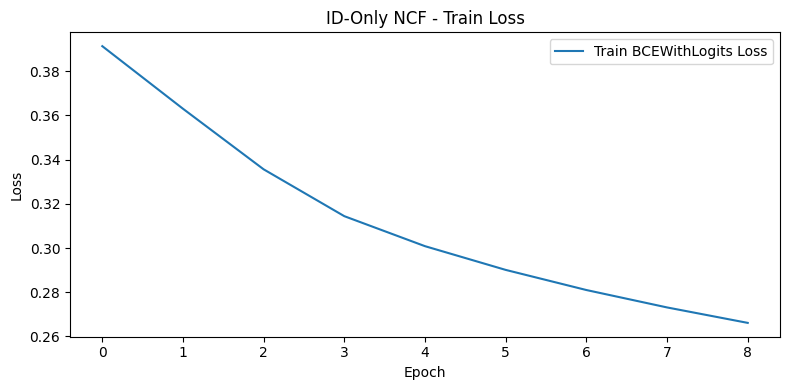

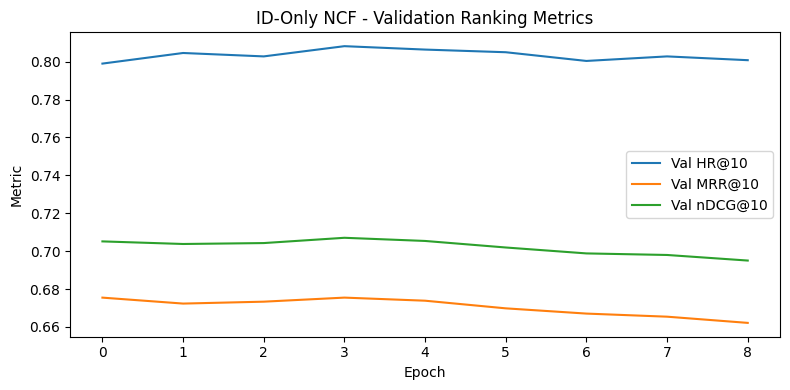

In [ ]:
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_ndcg = -1.0
patience = 5
patience_counter = 0
num_epochs = 10

K = 10

# Local save path during training
best_model_path = "global_temporal_best_ncf_idonly.pt"

# Drive save path after training
drive_model_path = DATA_DIR + "global_temporal_best_ncf_idonly.pt"

train_losses = []
val_ndcgs = []
val_hrs = []
val_mrrs = []

for epoch in tqdm(range(num_epochs), desc="Epoch progress", unit="epoch"):
    # ---------------- TRAIN ----------------
    model.train()
    epoch_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f"Train E{epoch+1:02d}", unit="batch", leave=False)
    for user, item, label in train_bar:
        user = user.to(DEVICE)
        item = item.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()

        logits = model(user, item)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        train_correct += (preds == label).sum().item()
        train_total += label.numel()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_loader)
    train_acc = train_correct / train_total if train_total else 0.0

    train_losses.append(avg_train_loss)

    # ---------------- VALIDATION ----------------
    val_metrics = evaluate_ranking_sampled_fast(
        model=model,
        eval_users=val_eval_users_sampled,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_book_ids=top_1000_books,
        device=DEVICE,
        k=K,
        n_neg=99,
        seed=SEED
    )

    val_hr = val_metrics[f"HR@{K}"]
    val_mrr = val_metrics[f"MRR@{K}"]
    val_ndcg = val_metrics[f"nDCG@{K}"]

    val_hrs.append(val_hr)
    val_mrrs.append(val_mrr)
    val_ndcgs.append(val_ndcg)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs}  "
        f"Train Loss: {avg_train_loss:.4f}  "
        f"Train Acc: {train_acc:.4f}  "
        f"Val HR@{K}: {val_hr:.4f}  "
        f"Val MRR@{K}: {val_mrr:.4f}  "
        f"Val nDCG@{K}: {val_ndcg:.4f}  "
        f"Val Users: {val_metrics['n_users']:,}"
    )

    if val_ndcg > best_ndcg:
        best_ndcg = val_ndcg
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model locally ({best_model_path}) (val nDCG@{K}: {best_ndcg:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

# Save best model to Drive
if os.path.exists(best_model_path):
    torch.save(torch.load(best_model_path, map_location="cpu"), drive_model_path)
    print(f"\nBest model also saved to Drive: {drive_model_path}")
else:
    print("\nWarning: local best model file not found, so nothing was copied to Drive.")

# Plot train loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train BCEWithLogits Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ID-Only NCF - Train Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot val metrics
plt.figure(figsize=(8, 4))
plt.plot(val_hrs, label=f"Val HR@{K}")
plt.plot(val_mrrs, label=f"Val MRR@{K}")
plt.plot(val_ndcgs, label=f"Val nDCG@{K}")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("ID-Only NCF - Validation Ranking Metrics")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on Test Set

In [ ]:
# ==========================================
# Final test evaluation (load best checkpoint)
# ==========================================

model.load_state_dict(torch.load(drive_model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

test_metrics = evaluate_ranking_sampled_fast(
    model=model,
    eval_users=test_eval_users_sampled,
    user_train_seen=user_train_seen,
    item_to_idx=item_to_idx,
    user_to_idx=user_to_idx,
    candidate_book_ids=top_1000_books,
    device=DEVICE,
    k=K,
    n_neg=999,
    seed=SEED,
)

print(f"Checkpoint loaded : {drive_model_path}")
print(f"Users evaluated   : {test_metrics['n_users']:,}")
print(f"HR@{K}            : {test_metrics[f'HR@{K}']:.4f}")
print(f"MRR@{K}           : {test_metrics[f'MRR@{K}']:.4f}")
print(f"nDCG@{K}          : {test_metrics[f'nDCG@{K}']:.4f}")

Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]

Checkpoint loaded : /content/drive/My Drive/BT4222Project/global_temporal_best_ncf_idonly.pt
Users evaluated   : 5,000
HR@10            : 0.6274
MRR@10           : 0.5658
nDCG@10          : 0.5801


# Performance by User Segment

To better understand where the ID-only NCF model performs well or poorly, we evaluate test ranking performance across user activity segments defined by the number of training interactions per user.

Two segmentations are used:

- **2-way split:** Dense users (`>= 5` training interactions) vs Sparse users (`< 5`)
- **3-way split:** Low (`1–5`), Medium (`6–38`), and High (`39+`) activity users

For each segment, we compute **HR@K**, **MRR@K**, and **nDCG@K** on the sampled warm-start test users using the same ranking evaluation protocol as the main test evaluation (`n_neg = 999`).

This analysis helps assess whether the pure collaborative filtering baseline depends strongly on user history length, which is especially important because ID-only models typically perform better for users with richer interaction histories.

In [ ]:
# ==========================================
# Segment analysis on sampled test users
# ==========================================
user_train_counts = train_df.groupby("user_id").size()

dense_users = set(user_train_counts[user_train_counts >= 5].index)
sparse_users = set(user_train_counts[user_train_counts < 5].index)

print(f"Dense users  (>= 5 train interactions): {len(dense_users):,}")
print(f"Sparse users (<  5 train interactions): {len(sparse_users):,}")

results = {}

segment_defs = [
    ("Dense (>=5)", dense_users),
    ("Sparse (<5)", sparse_users),
    ("All", set(uid for uid, _ in test_eval_users_sampled)),
]

for seg_name, seg_set in segment_defs:
    if seg_name == "All":
        seg_eval_users = test_eval_users_sampled
    else:
        seg_eval_users = [(uid, books) for uid, books in test_eval_users_sampled if uid in seg_set]

    if not seg_eval_users:
        print(f"\n{seg_name}: no users found")
        continue

    seg_metrics = evaluate_ranking_sampled_fast(
        model=model,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_book_ids=top_1000_books,
        device=DEVICE,
        k=K,
        n_neg=999,
        seed=SEED,
    )

    results[seg_name] = {
        "n_users": seg_metrics["n_users"],
        f"HR@{K}": round(seg_metrics[f"HR@{K}"], 4),
        f"MRR@{K}": round(seg_metrics[f"MRR@{K}"], 4),
        f"nDCG@{K}": round(seg_metrics[f"nDCG@{K}"], 4),
    }

    print(f"\n{seg_name} ({seg_metrics['n_users']:,} users)")
    print(f"  HR@{K}: {seg_metrics[f'HR@{K}']:.4f}")
    print(f"  MRR@{K}: {seg_metrics[f'MRR@{K}']:.4f}")
    print(f"  nDCG@{K}: {seg_metrics[f'nDCG@{K}']:.4f}")

seg_df = pd.DataFrame(results).T
print("\nSummary table:")
print(seg_df.to_string())

Dense users  (>= 5 train interactions): 214,060
Sparse users (<  5 train interactions): 196,680


Ranking eval:   0%|          | 0/3698 [00:00<?, ?it/s]


Dense (>=5) (3,698 users)
  HR@10: 0.6333
  MRR@10: 0.5839
  nDCG@10: 0.5954


Ranking eval:   0%|          | 0/1302 [00:00<?, ?it/s]


Sparse (<5) (1,302 users)
  HR@10: 0.6106
  MRR@10: 0.5144
  nDCG@10: 0.5367


Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]


All (5,000 users)
  HR@10: 0.6274
  MRR@10: 0.5658
  nDCG@10: 0.5801

Summary table:
             n_users   HR@10  MRR@10  nDCG@10
Dense (>=5)   3698.0  0.6333  0.5839   0.5954
Sparse (<5)   1302.0  0.6106  0.5144   0.5367
All           5000.0  0.6274  0.5658   0.5801


In [ ]:
# ==========================================
# 3-way activity bucket analysis
# ==========================================
user_train_counts_3way = train_df.groupby("user_id").size()

def activity_bucket_3way(n):
    if n <= 5:
        return "Low (1-5)"
    elif n <= 38:
        return "Medium (6-38)"
    else:
        return "High (39+)"

seg_results_3way = {}

for seg_name in ["Low (1-5)", "Medium (6-38)", "High (39+)", "All"]:
    if seg_name == "All":
        seg_eval_users = test_eval_users_sampled
    else:
        seg_eval_users = []
        for uid, books in test_eval_users_sampled:
            n_train = int(user_train_counts_3way.get(uid, 0))
            bucket = activity_bucket_3way(n_train)
            if bucket == seg_name:
                seg_eval_users.append((uid, books))

    if not seg_eval_users:
        print(f"\n{seg_name}: no users found")
        continue

    seg_metrics = evaluate_ranking_sampled_fast(
        model=model,
        eval_users=seg_eval_users,
        user_train_seen=user_train_seen,
        item_to_idx=item_to_idx,
        user_to_idx=user_to_idx,
        candidate_book_ids=top_1000_books,
        device=DEVICE,
        k=K,
        n_neg=999,
        seed=SEED,
    )

    seg_results_3way[seg_name] = {
        "n_users": seg_metrics["n_users"],
        f"HR@{K}": round(seg_metrics[f"HR@{K}"], 4),
        f"MRR@{K}": round(seg_metrics[f"MRR@{K}"], 4),
        f"nDCG@{K}": round(seg_metrics[f"nDCG@{K}"], 4),
    }

    print(f"\n{seg_name} ({seg_metrics['n_users']:,} users)")
    print(f"  HR@{K}: {seg_metrics[f'HR@{K}']:.4f}")
    print(f"  MRR@{K}: {seg_metrics[f'MRR@{K}']:.4f}")
    print(f"  nDCG@{K}: {seg_metrics[f'nDCG@{K}']:.4f}")

seg_df_3way = pd.DataFrame(seg_results_3way).T
print("\nSummary table:")
print(seg_df_3way.to_string())

Ranking eval:   0%|          | 0/1517 [00:00<?, ?it/s]


Low (1-5) (1,517 users)
  HR@10: 0.6144
  MRR@10: 0.5226
  nDCG@10: 0.5438


Ranking eval:   0%|          | 0/2203 [00:00<?, ?it/s]


Medium (6-38) (2,203 users)
  HR@10: 0.6010
  MRR@10: 0.5406
  nDCG@10: 0.5547


Ranking eval:   0%|          | 0/1280 [00:00<?, ?it/s]


High (39+) (1,280 users)
  HR@10: 0.6883
  MRR@10: 0.6604
  nDCG@10: 0.6670


Ranking eval:   0%|          | 0/5000 [00:00<?, ?it/s]


All (5,000 users)
  HR@10: 0.6274
  MRR@10: 0.5658
  nDCG@10: 0.5801

Summary table:
               n_users   HR@10  MRR@10  nDCG@10
Low (1-5)       1517.0  0.6144  0.5226   0.5438
Medium (6-38)   2203.0  0.6010  0.5406   0.5547
High (39+)      1280.0  0.6883  0.6604   0.6670
All             5000.0  0.6274  0.5658   0.5801


Under the global temporal evaluation setup, this ID-Only NCF performs reasonably well overall, but its performance is strongly history-dependent. Users with dense interaction histories benefit the most, while sparse-history users receive weaker recommendations. This indicates that the model is learning useful collaborative preference structure, but that its personalization ability remains constrained when past user signal is limited.